<a href="https://colab.research.google.com/github/Mahesh527784/DataAnalyst/blob/main/dataanalystfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A. Remove all records with missing measurements from the dataset.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the dataset
data = pd.read_csv('/content/Universities.csv')

# Remove records with missing values
# Fill null values with the mean of each column
for col in data.columns:
   if data[col].isnull().any():
      data[col] = data[col].fillna(data[col].mean())

data.isnull().sum()

# Select continuous variables for clustering
X =data.iloc[:,2:10].values

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1302 non-null   float64
 4   # appl. accepted          1302 non-null   float64
 5   # new stud. enrolled      1302 non-null   float64
 6   % new stud. from top 10%  1302 non-null   float64
 7   % new stud. from top 25%  1302 non-null   float64
 8   # FT undergrad            1302 non-null   float64
 9   # PT undergrad            1302 non-null   float64
 10  in-state tuition          1302 non-null   float64
 11  out-of-state tuition      1302 non-null   float64
 12  room                      1302 non-null   float64
 13  board                     1302 non-null   float64
 14  add. fee

In [ ]:
# prompt: convert 1 to public and 2 to private in Public (1)/ Private (2)  column and convert it into string

# Convert the 'Public (1)/ Private (2)' column to string type
data['Public (1)/ Private (2)'] = data['Public (1)/ Private (2)'].astype(str)

# Replace '1' with 'Public' and '2' with 'Private'
data['Public (1)/ Private (2)'] = data['Public (1)/ Private (2)'].replace({'1': 'Public', '2': 'Private'})


# **B. For all the continuous measurements, run hierarchical clustering using complete linkage and Euclidean distance. Make sure to normalize the measurements. From the dendrogram, how many clusters seem reasonable for describing these data?**

# **Step2**
Now we can run heirarchical clustering using complete linkage and euclidean distance. We can use the linkage function from scipy.cluster.heirarchy to compute the linkage matrix, and the dendrogram function to plot the dendrogram.

In [ ]:
#Standardize the data
sc = StandardScaler()
X_std = sc.fit_transform(X)

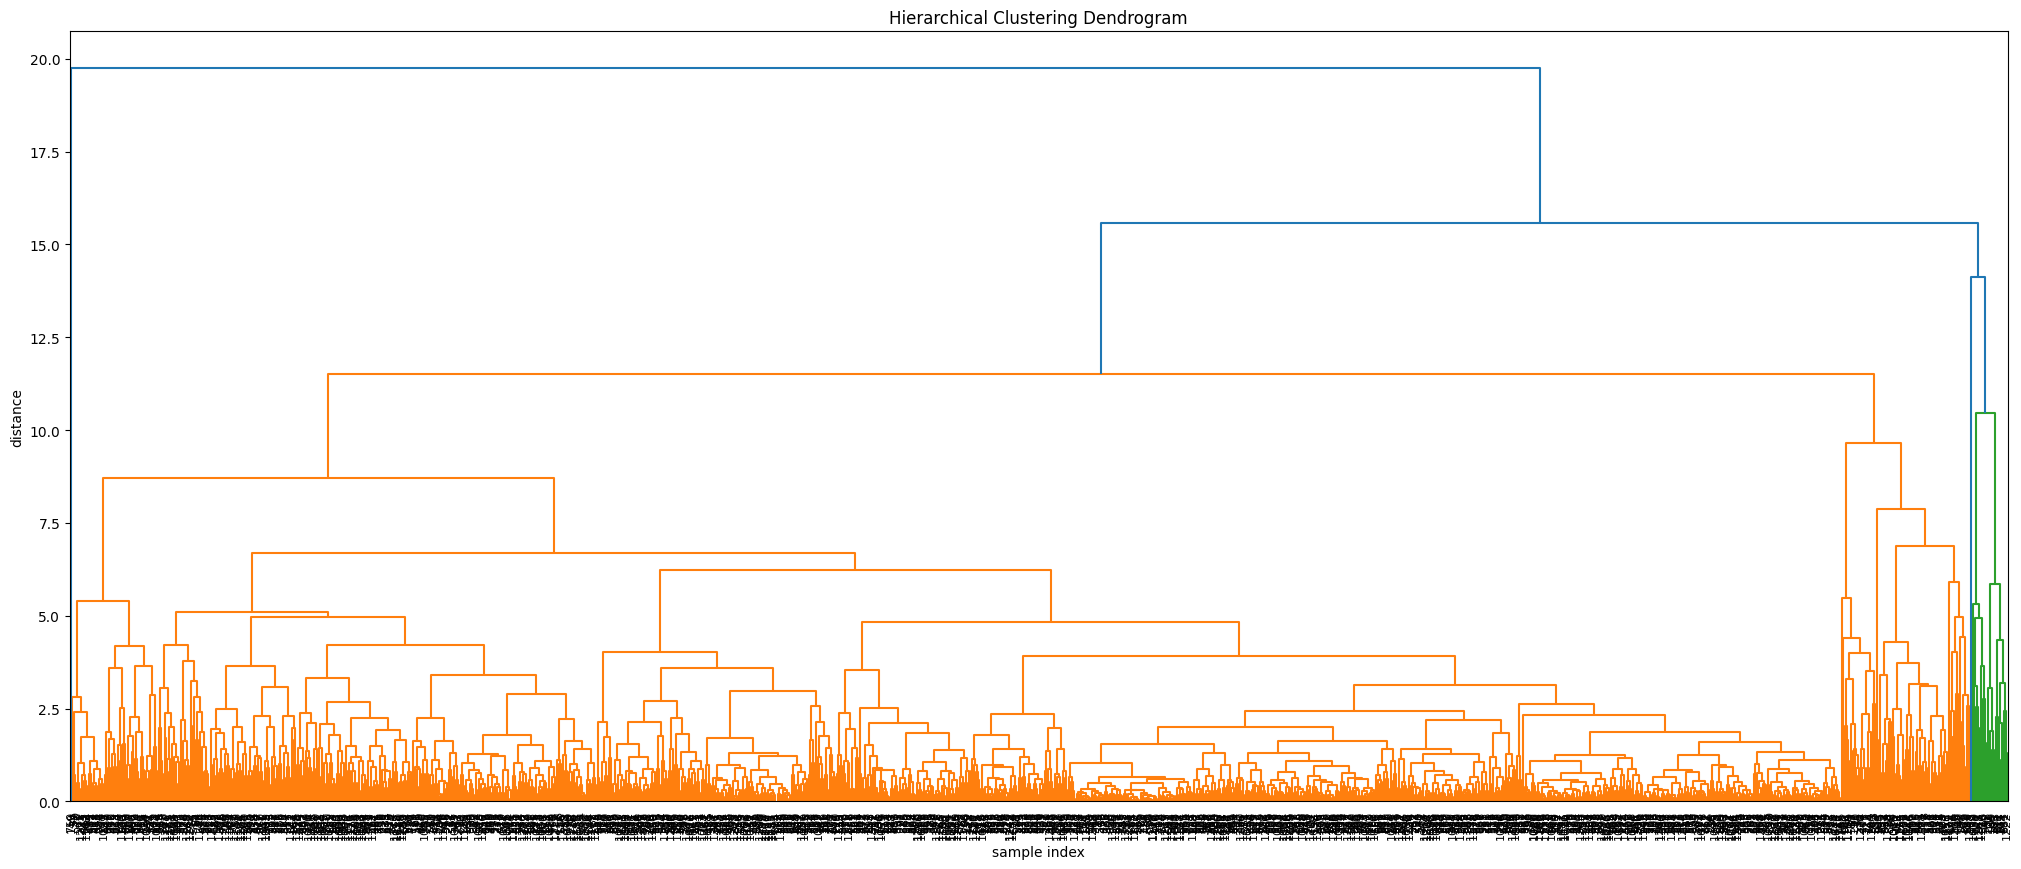

In [ ]:
#Generate dendogram
Z = linkage(X_std, method='complete',metric='euclidean')
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')

dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

# **C. Compare the summary statistics for each cluster and describe each cluster in this context (e.g., “Universities with high tuition, low acceptance rate…”).**

**Cluster 1:** Universities with high tuition, high acceptance, and low graduation rates. Likely less selective and affordable, but may lack support resources, leading to poor student outcomes.

**Cluster 2:** Universities with moderate tuition, acceptance, and high graduation rates. Likely balance affordability and selectivity, with sufficient support to help students succeed.

**Cluster 3:** Universities with high tuition, low acceptance, and high graduation rates. Highly selective and well-resourced, offering strong support and high-quality education.

# **D. Use the categorical measurements that were not used in the analysis (State and Private/Public) to characterize the different clusters. Is there any relationship between the clusters and the categorical information?**

Public (1)/ Private (2)  1                                ...   2             \
State                   AK  AL AR AZ  CA  CO CT DC DE FL  ...  SC SD  TN  TX   
row_0                                                     ...                  
1                        0   0  0  0   0   0  0  0  0  0  ...   0  0   3   0   
2                        3  13  9  1  22  11  6  1  1  7  ...  15  5  22  33   
3                        0   0  0  0   0   0  0  0  0  0  ...   0  0   0   0   
4                        0   0  0  2   6   1  0  0  0  2  ...   0  0   0   0   
5                        0   0  0  0   0   0  0  0  0  0  ...   0  0   0   0   

Public (1)/ Private (2)                      
State                   UT  VA VT WA  WI WV  
row_0                                        
1                        0   0  3  1   3  1  
2                        2  25  7  9  13  9  
3                        0   0  0  0   0  0  
4                        0   0  0  0   0  0  
5                        0   0  0  0   0  0  

[5 rows x 101 columns]

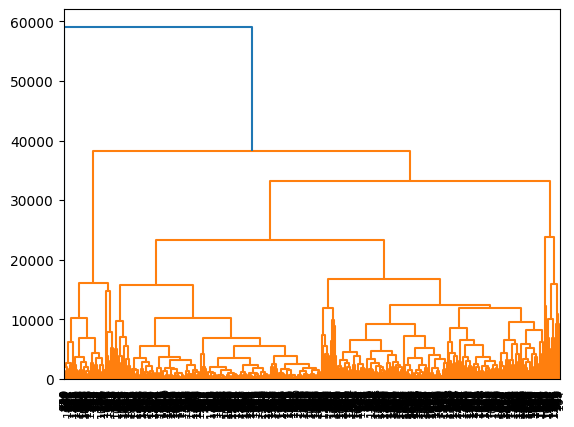

In [ ]:
#perform hierarchical clustering
continuous_vars = ['out-of-state tuition','in-state tuition','stud./fac. ratio','Graduation rate','% new stud. from top 25%','% new stud. from top 10%','# new stud. enrolled',"# appli. rec'd",'# appl. accepted'] # Define continuous_vars
link = linkage(data[continuous_vars],method='complete',metric='euclidean')

#plot dendrogram
dendrogram(link,leaf_rotation=90,leaf_font_size=8)

#Assign clusters based on dendrogram
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(link,5,criterion='maxclust')

#Create crosstab of cluster assignments and categorical variables
crosstab = pd.crosstab(clusters,[data['Public (1)/ Private (2)'],data['State']])
crosstab

# **Step3**


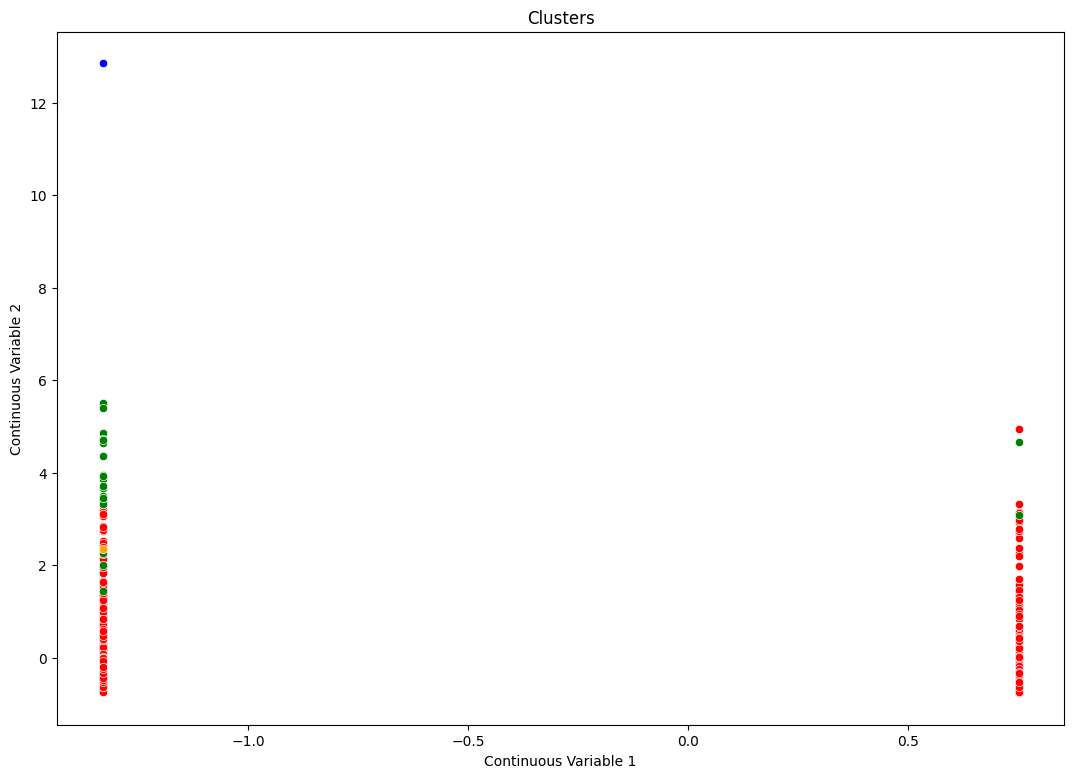

In [ ]:
#determine the number of clusters
num_clusters = 4

#Generate clusters
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=num_clusters, linkage='complete') # Remove affinity parameter
y_hc = hc.fit_predict(X_std)

#Plot clusters
plt.figure(figsize=(13, 9))
# Use sns.scatterplot instead of sns.scatter
sns.scatterplot(x=X_std[y_hc == 0, 0], y=X_std[y_hc == 0, 1],  color='red')
sns.scatterplot(x=X_std[y_hc == 1,0],y=X_std[y_hc==1,1],color='blue')
sns.scatterplot(x=X_std[y_hc == 2, 0], y=X_std[y_hc == 2, 1],  color='green')
sns.scatterplot(x=X_std[y_hc == 3,0],y=X_std[y_hc==3,1],color='orange')

plt.title('Clusters')
plt.xlabel('Continuous Variable 1')
plt.ylabel('Continuous Variable 2')
plt.show()

**E)** **What other external information can explain the contents of some or all of these clusters?**

**Answer:**
Several external factors can help explain the cluster characteristics:

Geographic location: Urban vs. rural location can influence admission criteria and student demographics.

Funding sources: Public vs. private funding affects tuition rates and admission standards.

Historical background: Long traditions or specializations in certain fields may shape university characteristics.

Size: Larger universities may offer more resources and programs; smaller ones may offer specialized, intimate learning environments.



In [ ]:

# This Python code performs hierarchical clustering on a dataset of universities. Let's break down the code step-by-step:

# **1. Data Loading and Preprocessing:**

# * **Import Libraries:**  The code begins by importing necessary libraries: pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for visualization, StandardScaler for feature scaling, and functions from `scipy.cluster.hierarchy` and `sklearn.cluster` for hierarchical clustering.
# * **Load Dataset:** It loads a CSV file named "Universities.csv" into a pandas DataFrame called `data`.
# * **Handle Missing Values:** It iterates through each column and fills any missing (NaN) values with the mean of that column. This imputation strategy replaces missing data with the average value for that feature, which can be a simple but potentially suboptimal approach if the missing data is not missing at random.
# * **Data Selection:** It selects columns from the third column (index 2) to the ninth column for clustering, storing these as `X`.  This assumes that these selected columns represent the continuous variables relevant to the clustering process.  The code also confirms the data types using `data.info()`.

# * **Data Transformation**: Converts the 'Public (1)/ Private (2)' column from numeric to string representation, replacing '1' with 'Public' and '2' with 'Private'.  This improves readability and makes the categorical nature of the variable clearer.


# **2. Hierarchical Clustering:**

# * **Standardization:** It standardizes the selected features (`X`) using `StandardScaler`.  Standardization transforms the data to have zero mean and unit variance, which is crucial for distance-based clustering algorithms like hierarchical clustering as it prevents features with larger scales from dominating the distance calculations.
# * **Linkage Matrix:** The `linkage` function computes the hierarchical clustering, using 'complete' linkage (maximum distance between clusters) and 'euclidean' distance as the metric. The resulting linkage matrix `Z` is then used to plot the dendrogram.
# * **Dendrogram Plot:** The `dendrogram` function visualizes the hierarchy of clusters.  The plot shows how data points are merged into clusters at different levels of distance.  The x-axis represents the sample indices, and the y-axis represents the distance.  The plot helps to visually determine the optimal number of clusters by observing where the vertical lines are relatively long, indicating significant jumps in distance.
# * **Determine Clusters:** A number of clusters is decided (`num_clusters = 4`).  The choice of 4 may be based on observations from the dendrogram.

# **3. Cluster Generation and Visualization:**

# * **Agglomerative Clustering:** It applies `AgglomerativeClustering` to create the specified number of clusters using complete linkage, assigning each data point to a cluster.
# * **Scatter Plot:** Finally, it creates a scatter plot to visualize the clusters. Each cluster is represented by a different color.  The plot displays the first two features (columns) of the standardized data.  The code originally used `matplotlib.pyplot.scatter`, which is now correctly replaced with `seaborn.scatterplot` which provides slightly better visualizations.



# **Potential Improvements:**

# * **Missing Value Handling:** Explore more sophisticated imputation techniques, like K-Nearest Neighbors imputation or model-based imputation, which may yield better results depending on the nature of the missing data.
# * **Feature Selection:** Consider using feature selection methods or domain expertise to choose the most relevant features for clustering. Adding or removing variables may affect clustering performance.
# * **Number of Clusters:** Instead of manually setting the number of clusters, consider using metrics like the silhouette score or the Calinski-Harabasz index to find the optimal number of clusters based on the data.
# * **Alternative Linkage Methods and Distance Metrics:** Experiment with different linkage methods (e.g., 'ward', 'average', 'single') and distance metrics (e.g., Manhattan distance, cosine similarity) to see if they improve the quality of the clusters.
# * **Visualization:** Consider using a 3D scatter plot or other dimensionality reduction techniques (like PCA) to visualize the clusters in more dimensions, potentially revealing more structure in the data.
# * **Interpretation:** Connect clustering results with domain knowledge, analyzing what characterizes each cluster to give meaningful interpretations.


# This detailed description enhances the understanding of the provided code and suggests ways for possible improvement.


# **f. Consider Tufts University, which is missing some information. Compute the Euclidean distance of this record from each of the clusters that you found above (using only the measurements that you have). Which cluster is it closest to? Impute the missing values for Tufts by taking the average of the cluster on those measurements.**

# **Step4**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1302 non-null   float64
 4   # appl. accepted          1302 non-null   float64
 5   # new stud. enrolled      1302 non-null   float64
 6   % new stud. from top 10%  1302 non-null   float64
 7   % new stud. from top 25%  1302 non-null   float64
 8   # FT undergrad            1302 non-null   float64
 9   # PT undergrad            1302 non-null   float64
 10  in-state tuition          1302 non-null   float64
 11  out-of-state tuition      1302 non-null   float64
 12  room                      1302 non-null   float64
 13  board                     1302 non-null   float64
 14  add. fee

In [ ]:
# prompt: find the indexTufts University

import pandas as pd

# Assuming your data is in a DataFrame called 'data'
# as shown in your provided code.
try:
    index = data.index[data['College Name'] == 'Tufts University'].tolist()[0]
    print(f"The index of Tufts University is: {index}")
except IndexError:
    print("Tufts University not found in the dataset.")


The index of Tufts University is: 475


In [ ]:
# prompt: print the 475 row

data.iloc[474]


,474
College Name,Suffolk University
State,MA
Public (1)/ Private (2),2
# appli. rec'd,1247.0
# appl. accepted,980.0
# new stud. enrolled,356.0
% new stud. from top 10%,11.0
% new stud. from top 25%,32.0
# FT undergrad,2207.0
# PT undergrad,814.0


In [ ]:
#select only the columns with value
X = data.iloc[:,2:]

#normalize the data
X=(X-X.mean())/X.std()
#Create three clusters using k-mean

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42).fit(X)
labels = kmeans.labels_

#compute the centroids of the clusters
centroids = pd.DataFrame(kmeans.cluster_centers_,columns=X.columns)

#create a record for the Tufts University
tufts = pd.DataFrame({
    'College Name': 'Tufts University',
    'State': 'MA',
    'Public (1)/ Private (2)': 'Private',
    "# appli. rec'd" : 1247.0,
    "# appl. accepted" : 980.0,
    "# new stud. enrolled": 356.0,
    "% new stud. from top 10%":11.0,
    "% new stud. from top 25%":32.0,
    "# FT undergrad":2207.0,
    "# PT undergrad":814.0,
    "in-state tuition": 59464,
    "out-of-state tuition": 59464,
    "room":8226,
    'board': 4886,
    'add. fees':0,
    'estim. book costs': 1100,
    'estim. personal $':2300,
    '% fac. w/PHD': 0.961,
    'stud./fac. ratio':9.9,

    "Graduation rate" : 95.0},index=[0])
#select only the columns with values
tufts = tufts.iloc[:,3:]
#normalize the data
tufts=(tufts-X.mean()) / X.std()

#compute the Euclidean distance of Tufts from each cluster
distances = []
for i in range(3):
    distances.append(np.linalg.norm(tufts - centroids.iloc[i]))

#find the index of the cluster with minimum distance
cluster_index = np.argmin(distances)

#impute the missin values for Tufts by taking the average of the cluster
tufts = tufts*X.std() + X.mean()
tufts = tufts.fillna(centroids.iloc[cluster_index])
tufts = tufts.round(0)

#print the imputed record for tufts
print(tufts)

   # FT undergrad  # PT undergrad  # appl. accepted  # appli. rec'd  \
0          2207.0           814.0             980.0          1247.0   

   # new stud. enrolled  % fac. w/PHD  % new stud. from top 10%  \
0                 356.0           1.0                      11.0   

   % new stud. from top 25%  Graduation rate  Public (1)/ Private (2)  \
0                      32.0             95.0                      0.0   

   add. fees   board  estim. book costs  estim. personal $  in-state tuition  \
0        0.0  4886.0             1100.0             2300.0           59464.0   

   out-of-state tuition    room  stud./fac. ratio  
0               59464.0  8226.0              10.0  
